In [1]:
print("Alhamdullilah")

Alhamdullilah


In [1]:
import pandas as pd

df = pd.read_csv("data/Telco_Customer_Churn.csv")

columns = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# print(df.dtypes)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df = df.dropna(subset=["TotalCharges"])
df = df.drop(columns=["customerID"])

In [3]:
# Defining X & y
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(columns=["Churn"])
y = df["Churn"]

print(X.dtypes)
print(y.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object
int64


In [4]:
# Explore target
y.value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [5]:
# Test & Train
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Separate numerical & categorical columns

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [6]:
# Build preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
    ]
)

In [7]:
# Build Logistic Regression Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train model
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
# Class Prediction
y_pred = model.predict(X_test)

# Probability
y_prob = model.predict_proba(X_test)[:, 1]

print(y_pred)
print(y_prob)

[0 1 0 ... 0 0 0]
[0.02234879 0.60889184 0.01241035 ... 0.1041126  0.02910305 0.00714146]


In [9]:
# Evaluate model
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_auc_score

print("Accuracy Score: ",accuracy_score(y_test, y_pred))
print("Precision Score: ",precision_score(y_test, y_pred))
print("F1 Score: ",f1_score(y_test, y_pred))
print("Recall Score: ",recall_score(y_test, y_pred))

print("Confusion Matrix: \n",confusion_matrix(y_test, y_pred))
print("Classification Report: \n",classification_report(y_test, y_pred))

print("ROC AUC Score: ",roc_auc_score(y_test, y_prob))

Accuracy Score:  0.7938877043354655
Precision Score:  0.6288343558282209
F1 Score:  0.5857142857142857
Recall Score:  0.5481283422459893
Confusion Matrix: 
 [[912 121]
 [169 205]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.55      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.72      1407
weighted avg       0.79      0.79      0.79      1407

ROC AUC Score:  0.8351525332477443


In [10]:
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[912 121]
 [169 205]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.55      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.72      1407
weighted avg       0.79      0.79      0.79      1407



In [13]:
results = X_test.copy()

results["actual_churn"] = y_test
results["predicted_churn"] = y_pred

results["predicted_churn"] = results["predicted_churn"].map({
    0: "No Churn",
    1: "Churn"
})

results["actual_churn"] = results["actual_churn"].map({
    0: "No Churn",
    1: "Churn"
})

results[["actual_churn", "predicted_churn"]]

,actual_churn,predicted_churn
974,No Churn,No Churn
619,No Churn,Churn
4289,No Churn,No Churn
3721,Churn,No Churn
4533,No Churn,No Churn
...,...,...
4829,No Churn,No Churn
5176,No Churn,No Churn
2750,No Churn,No Churn
4432,No Churn,No Churn


In [18]:
print(df["Churn"].value_counts(normalize=True)*100)
print(results["predicted_churn"].value_counts(normalize=True)*100)
print(results["actual_churn"].value_counts(normalize=True)*100)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64
predicted_churn
No Churn    76.830135
Churn       23.169865
Name: proportion, dtype: float64
actual_churn
No Churn    73.418621
Churn       26.581379
Name: proportion, dtype: float64


In [25]:
pd.crosstab(
    df["Contract"],
    df["Churn"].value_counts()
)

count,1869,5163
Contract,,
Month-to-month,0,1
One year,1,0


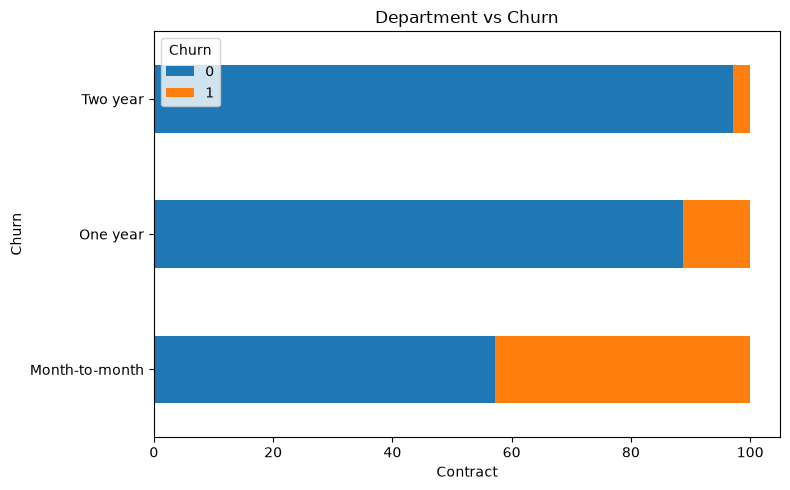

In [23]:
import matplotlib.pyplot as plt

ct = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

ct.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 5)
)

plt.xlabel("Contract")
plt.ylabel("Churn")
plt.title("Department vs Churn")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
pd.crosstab(
    results["predicted_churn"],
    results["actual_churn"],
    normalize="index"
) * 100

actual_churn,Churn,No Churn
predicted_churn,,
Churn,62.883436,37.116564
No Churn,15.633673,84.366327


In [41]:
logreg = model.named_steps["classifier"]

logreg.coef_ # This output doesn't bring useful info to the table

pp = model.named_steps["preprocessor"]

feature_names = pp.get_feature_names_out()

print(feature_names.shape)

(101,)


In [42]:
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logreg.coef_[0]
})

coefficients

,feature,coefficient
0,num__tenure,-1.268322
1,num__MonthlyCharges,-0.205993
2,num__TotalCharges,0.149728
3,cat__gender_Male,-0.028555
4,cat__SeniorCitizen_1,0.199359
...,...,...
96,cat__Contract_Two year,-1.438539
97,cat__PaperlessBilling_Yes,0.294746
98,cat__PaymentMethod_Credit card (automatic),0.053029
99,cat__PaymentMethod_Electronic check,0.351802


In [44]:
# Sort the coefficients
coefficients.sort_values(
    "coefficient",
    ascending=False
)

# Largest positive coefficients are associated with higher predicted churn probability
# While negative coefficients are associated with lower prediction churn probability

,feature,coefficient
75,cat__tenure_70,1.076665
81,cat__InternetService_Fiber optic,1.064644
71,cat__tenure_66,0.975639
58,cat__tenure_53,0.822373
74,cat__tenure_69,0.799244
...,...,...
39,cat__tenure_34,-0.963174
32,cat__tenure_27,-0.977445
28,cat__tenure_23,-1.171922
0,num__tenure,-1.268322


In [46]:
# Convert coefficients into odd ratios
import numpy as np

coefficients["odd_ratio"] = np.exp(
    coefficients["coefficient"]
)

coefficients.sort_values(
    "odd_ratio",
    ascending=False
).head(10)

,feature,coefficient,odd_ratio
75,cat__tenure_70,1.076665,2.934876
81,cat__InternetService_Fiber optic,1.064644,2.899807
71,cat__tenure_66,0.975639,2.652861
58,cat__tenure_53,0.822373,2.275895
74,cat__tenure_69,0.799244,2.223860
63,cat__tenure_58,0.786108,2.194837
72,cat__tenure_67,0.748300,2.113405
73,cat__tenure_68,0.736985,2.089626
59,cat__tenure_54,0.697185,2.008092
52,cat__tenure_47,0.484440,1.623265


In [ ]:
from sklearn.model_selection import GridSearchCV

